# Oluwafemi Gabriel, James
## Natural Language Processing: Sentiment Analysis

### Starbucks Reviews Dataset



Link to dataset: https://www.kaggle.com/datasets/harshalhonde/starbucks-reviews-dataset

## Introduction

This project focuses on performing Sentiment Analysis on a comprehensive collection of Starbucks consumer reviews, collected via web scraping from ConsumerAffairs.

<b>The objective is twofold:</b>

- Technical: Master the methodology of sentiment classification by applying and evaluating both traditional lexicon-based models (VADER) and classical Machine Learning algorithms (Naïve Bayes and Support Vector Machines).
- Business: Extract actionable customer insights from raw text that directly inform Starbucks' core business strategy, namely, improving the premium customer experience and resolving localized operational pain points.

The dataset includes crucial features for this analysis: the Rating (a direct numerical measure of satisfaction) and the Review text (the rich source of sentiment and context).

## Business Understanding

Starbucks' business model is fundamentally built on the "Starbucks Experience", a blend of high-quality products, personalized service, and a welcoming atmosphere. Customer feedback, especially in the form of detailed reviews, is a strategic asset that directly impacts brand reputation, customer loyalty, and ultimately, financial performance.

<b>The sentiment analysis conducted in this project addresses the following critical business needs:</b>

##### Quantifying the Customer Experience (CX) Gap:
By classifying reviews into positive, negative, and neutral sentiments, we can precisely quantify the proportion of satisfied versus dissatisfied customers. This analysis serves as a vital health check for the brand's overall CX scores.
- Goal: Use the Rating column to train and validate our sentiment models, allowing Starbucks to predict customer satisfaction from any unstructured text source (like social media).

##### Identifying Operational Hotspots:
Uncovering the specific aspects of the service or product that drive negative sentiment. Starbucks relies on operational efficiency (e.g., speed of service, order accuracy) and partner (employee) engagement.
- Goal: Identify key negative topics (e.g., "slow time," "wrong order," "rude manager") and correlate them with the location and date to enable targeted interventions and training programs.

##### Benchmarking Modeling Performance:
Starbucks, like many large corporations, leverages various data science techniques. This project will compare the efficiency and accuracy of a rapid Lexicon-Based approach (VADER) against more sophisticated, data-driven Machine Learning models (NB, SVM).
- Goal: Provide a clear recommendation on the best-performing and most scalable model for real-time sentiment monitoring of unstructured customer data.

By successfully executing this sentiment analysis workflow, the project moves beyond mere data reporting to deliver a tool that supports data-driven decision-making aimed at strengthening customer loyalty and driving market share in the highly competitive coffee industry.

## Data Understanding

#### Evaluation Against Criteria

1. <b>Relevance to Study Objectives (Sentiment Analysis):</b> The dataset is highly relevant to the project objectives. The goal is to perform sentiment analysis, and the Review column provides rich, unstructured text data perfectly suited for this task. The accompanying Rating column serves as the ground truth (label) needed for training and evaluating supervised machine learning models (Naïve Bayes and SVM) for sentiment classification.

2. <b>Accessibility and Format:</b> The data is readily accessible, having been provided as a standard CSV file (reviews_data.csv). This format is universally compatible with data analysis tools and is the preferred input for the Pandas library in Python, simplifying the data loading and initial processing steps.

3. <b>Size and Manageability:</b> With 850 reviews, the dataset is highly manageable for this project. It is small enough to allow for rapid pre-processing and iterative model training for both lexicon-based and classical machine learning algorithms, avoiding the computational overhead associated with very large datasets.

4. <b>Assessment of Quality</b>

The dataset quality is generally good but presents a key challenge in the target variable:

- Completeness: The primary feature for text analysis, Review, is 100% complete (850 non-null values). However, the crucial target variable, Rating, has 145 missing values (17.06%). This will necessitate a data imputation or row-dropping strategy during the machine learning preparation phase.
- Accuracy & Reliability: The data is drawn from a public consumer review site (ConsumerAffairs), offering genuine, real-world customer opinions. The strong negative skew (mean rating ≈1.87) suggests the platform may attract a disproportionate number of highly negative experiences, which is a common characteristic of online review data.
- Text Quality: The Review column contains noise, such as generic entries like "No Review Text" (about 4% of entries), which will need to be cleaned during pre-processing to maintain data integrity for NLP.

## 1. Data Collection and Description

In [1]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import string
import nltk
import time
import re
import joblib
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import LinearSVC, SVC
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import Starbucks Reviews data

reviews_df = pd.read_csv("./reviews_data.csv")

In [3]:
reviews_df.head() # Preview first few rows of the dataset

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


In [4]:
reviews_df.tail() # Preview last few rows of the dataset

,name,location,Date,Rating,Review,Image_Links
845,Becky,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,I ordered two venti frappacino's without whipp...,['No Images']
846,Bob,"Goodrich, MI","Reviewed Jan. 3, 2005",NaN,No Review Text,['No Images']
847,Erik,"Valley Village, CA","Reviewed Nov. 5, 2004",NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",['No Images']
848,Andrew,"Fallbrook, CA","Reviewed Oct. 20, 2004",NaN,No Review Text,['No Images']
849,Christian,"Ramsey, NJ","Reviewed July 19, 2000",NaN,No Review Text,['No Images']


In [5]:
reviews_df.info() # Reviewing the dataframe information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         850 non-null    object 
 1   location     850 non-null    object 
 2   Date         850 non-null    object 
 3   Rating       705 non-null    float64
 4   Review       850 non-null    object 
 5   Image_Links  850 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB


In [6]:
reviews_df.describe() # Reviewing the statistical description of the dataset

,Rating
count,705.000000
mean,1.870922
std,1.397672
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5.000000


In [7]:
reviews_df.shape # Reviewing the dataframe structure

(850, 6)

In [8]:
reviews_df.isnull().sum() # Checking the total sum of null values in the data

name             0
location         0
Date             0
Rating         145
Review           0
Image_Links      0
dtype: int64

<b>Observations:</b> (Pre-Processing Assessment)

The Starbucks Reviews dataset comprises 850 entries and 6 columns. The initial assessment reveals critical data quality and distribution issues that must be addressed before proceeding to Sentiment Analysis.

#### Key Findings & Required Actions

1. <b>Missing Target Variable (Critical):</b> The Rating column, which serves as the ground truth for supervised machine learning, contains 145 missing values (17.06% of the total 850 entries). These rows must either be dropped or have their ratings imputed to enable model training.
2. <b>Severe Negative Skew in Ratings:</b>  The rated reviews show a mean rating of 1.87 and a median of 1.00 out of 5. This severe negative bias indicates that the dataset is highly imbalanced toward dissatisfaction. This imbalance requires careful selection of evaluation metrics (e.g., Precision, Recall, F1-score) rather than relying solely on accuracy.
3. <b>Review Text Quality Issue:</b> While the Review column is 100% non-null, the preview data reveals placeholder entries like "No Review Text". These non-informative rows must be identified and removed during Text Pre-processing to prevent them from negatively impacting the NLP feature extraction and model training.
4. <b>Feature Type Conversion:</b> The Date column is currently stored as a generic object (string) type and will require conversion to a datetime format for any temporal analysis or time-series-based model evaluation.

In summary, the data is loaded successfully, but significant effort is required to clean the Review text, handle missing Rating values, and address the imbalanced sentiment distribution before accurate lexicon-based or machine learning sentiment classification can begin.

## 2. Text Pre-Processing 

<b>Strategy to Maximize Data Usage</b>

To avoid "undersampling" (dropping data) while maintaining the integrity of the supervised learning part of the project, the approach is;

1. <b>Supervised Learning (NB & SVM):</b> Drop rows with missing Rating (145 rows). Use only 705 rows (Verified Labels)
2. <b>Unsupervised Learning (VADER):</b> Use all 850 rows, including the 145 missing Rating rows (All Text Data).
3. <b>Imputation/Prediction</b>: Use the trained ML models (NB or SVM) to predict the ratings for the 145 missing rows after the models are built. 145 rows (Predicted Labels)

### 2.1. NLP Pre-processing functions

In [9]:
# Define NLP Pre-processing Functions

lemmatizer = WordNetLemmatizer() # Initialization
custom_stopwords = set(stopwords.words('english'))

In [10]:
# Add context-specific stopwords

custom_stopwords.update(['starbucks', 'store', 'location', 'review', 'just'])

In [11]:
# Helper Function for POS Tagging

def get_wordnet_pos(pos_tag):
    """Maps NLTK POS tag to WordNet POS tag (required for accurate lemmatization)."""
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        # Default to Noun if tag is not found or is a punctuation/symbol
        return wordnet.NOUN

In [12]:
def preprocess_text(text):
    """
    Performs full text cleaning, tokenization, stop word removal, 
    POS tagging, and intelligent lemmatization.
    """
    # 1. Cleaning: Lowercase, remove URLs, HTML, and Numbers
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+|<.*?>|\d+', '', text)
    
    # 2. Tokenization and Punctuation Removal (combined step)
    # Tokenize first, then remove punctuation tokens later for cleaner processing
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in string.punctuation]

    # 3. Stop Word Removal
    tokens = [w for w in tokens if w not in custom_stopwords]
    
    # 4. POS Tagging and Lemmatization
    tagged_tokens = nltk.pos_tag(tokens)
    
    lemmatized_words = []
    for word, tag in tagged_tokens:
        w_pos = get_wordnet_pos(tag)
        # Lemmatize the word using its determined POS tag
        lemmatized_words.append(lemmatizer.lemmatize(word, pos=w_pos))
        
    # 5. Rejoin and return the processed string
    return " ".join(lemmatized_words)

### 2.2. Prepare Data for ML Training (NB and SVM)

In [13]:
# Create the training/evaluation dataset (only verified labels)
# This avoid losing data integrity for supervised models.

reviews_df_train = reviews_df.dropna(subset=['Rating']).copy()

In [14]:
# Clean 'Review' column - Remove 'No Review Text' placeholder
# We must ensure no empty/placeholder text remains.

reviews_df_train = reviews_df_train[reviews_df_train['Review'] != 'No Review Text']

In [15]:
# Convert Rating to Integer

reviews_df_train['Rating'] = reviews_df_train['Rating'].astype(int)

In [16]:
# Apply Pre-processing Pipeline to Training Data

# Apply the single, consolidated function
reviews_df_train['Review_Processed'] = reviews_df_train['Review'].apply(preprocess_text)

In [17]:
# 4. Final Preview of Training data

print(f"Dataset size for ML Training Data and Full Text Analysis: {len(reviews_df_train)}")
reviews_df_train[['Rating', 'Review', 'Review_Processed']].head()

Dataset size for ML Training Data and Full Text Analysis: 703


,Rating,Review,Review_Processed
0,5,Amber and LaDonna at the Starbucks on Southwes...,amber ladonna southwest parkway always warm we...
1,5,** at the Starbucks by the fire station on 436...,fire station altamonte spring fl make day fina...
2,5,I just wanted to go out of my way to recognize...,want go way recognize employee billy franklin ...
3,5,Me and my friend were at Starbucks and my card...,friend card ’ work thankful worker pay drink n...
4,5,I’m on this kick of drinking 5 cups of warm wa...,’ kick drinking cup warm water work instacart ...


### 2.2. Prepare Full Data (for VADER and later prediction)

In [18]:
# Create the full dataset for VADER analysis and later prediction of missing values

reviews_df_full = reviews_df.copy()

In [19]:
# Apply Pre-processing Pipeline to full Data for Vader Prediction
# Remove 'No Review Text' (4% of data)

reviews_df_full['Review_Processed'] = reviews_df_full['Review'].apply(preprocess_text)

In [20]:
# Handle Missing Ratings
# Fill NaN ratings with -1. This allows us to keep the full dataset 
# while distinguishing verified ratings (1-5) from unverified ones (-1).
reviews_df_full['Rating'] = reviews_df_full['Rating'].fillna(-1).astype(int)

In [21]:
# 4. Verification and Preview 

print(f"Dataset size for VADER and Full Text Analysis: {len(reviews_df_full)}")
reviews_df_full[['Rating', 'Review', 'Review_Processed']].head()

Dataset size for VADER and Full Text Analysis: 850


,Rating,Review,Review_Processed
0,5,Amber and LaDonna at the Starbucks on Southwes...,amber ladonna southwest parkway always warm we...
1,5,** at the Starbucks by the fire station on 436...,fire station altamonte spring fl make day fina...
2,5,I just wanted to go out of my way to recognize...,want go way recognize employee billy franklin ...
3,5,Me and my friend were at Starbucks and my card...,friend card ’ work thankful worker pay drink n...
4,5,I’m on this kick of drinking 5 cups of warm wa...,’ kick drinking cup warm water work instacart ...


<b>Observations:</b> Dual Dataset Preparation for VADER and ML

The preprocessing phase successfully created two distinct, purpose-built datasets from the original data, ensuring optimal integrity for Supervised Machine Learning (NB, SVM) while maximizing text utility for Lexicon-Based Sentiment Analysis (VADER).

1. <b>NLP Pipeline and Feature Creation:</b> A comprehensive and robust text preprocessing function (preprocess_text) was executed across all text. This function intelligently:

- Removes noise (URLs, HTML, numbers, punctuation).
- Filters out generic stopwords (including custom terms like 'starbucks').
- Performs POS-tagged Lemmatization, which is critical for accurate text normalization (e.g., distinguishing "running" (verb) from "running" (noun)).

This process creates the standardized feature Review_Processed, which is the required input for all subsequent models.

2. <b>Data Structure and Strategic Data Handling:</b>

- <b>reviews_df_train</b> for Supervised ML Training (NB, SVM) has ≈700 rows Verified with the original 1−5 star ratings. Ready for Train/Test Split and Vectorization for ML model training.
- <b>reviews_df_full</b> for VADER Analysis & ML Prediction has ≈830 rows. Missing ratings are strategically set to −1. Ready for immediate lexicon-based scoring.
- ML: Reserves the −1 rows for prediction using the models trained on reviews_df_train.

This dual-dataset approach addresses the primary data quality challenge, the 17% missing ratings, by avoiding arbitrary imputation that would compromise the ground truth labels for supervised learning. The result is a clean, normalized, and strategically partitioned data environment, making the project fully ready for both VADER and ML-based sentiment modeling.

## 3. Data Exploration 

### 3.1. Univariate Analysis

In [22]:
# Function to map 1-5 Rating to Tertiary Sentiment Label

def get_tertiary_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else: # Rating 1 or 2
        return 'Negative'

reviews_df_train['Sentiment_Label'] = reviews_df_train['Rating'].apply(get_tertiary_sentiment)

In [23]:
# Calculate Distribution

sentiment_distribution = reviews_df_train['Sentiment_Label'].value_counts(normalize=True).mul(100).round(2)
print(" Sentiment Distribution (%) \n")
print(sentiment_distribution)

 Sentiment Distribution (%) 

Sentiment_Label
Negative    77.95
Positive    17.35
Neutral      4.69
Name: proportion, dtype: float64


### Visualization

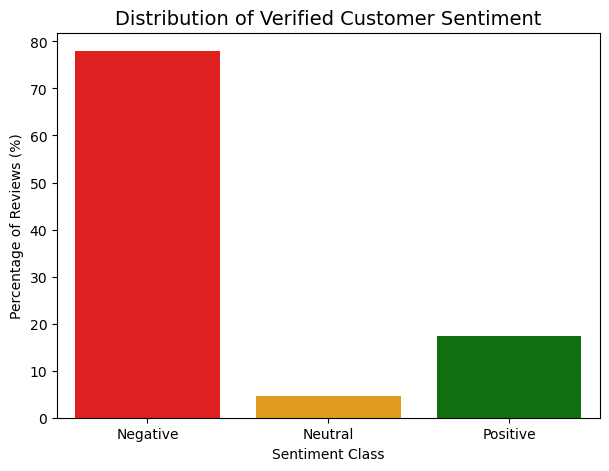

In [24]:
# Sentiment Bar Chart

plt.figure(figsize=(7, 5))
sns.barplot(
    x=sentiment_distribution.index, 
    y=sentiment_distribution.values, 
    palette={'Negative': 'red', 'Neutral': 'orange', 'Positive': 'green'}, 
    order=['Negative', 'Neutral', 'Positive']
)
plt.title('Distribution of Verified Customer Sentiment', fontsize=14)
plt.ylabel('Percentage of Reviews (%)')
plt.xlabel('Sentiment Class')
plt.show()

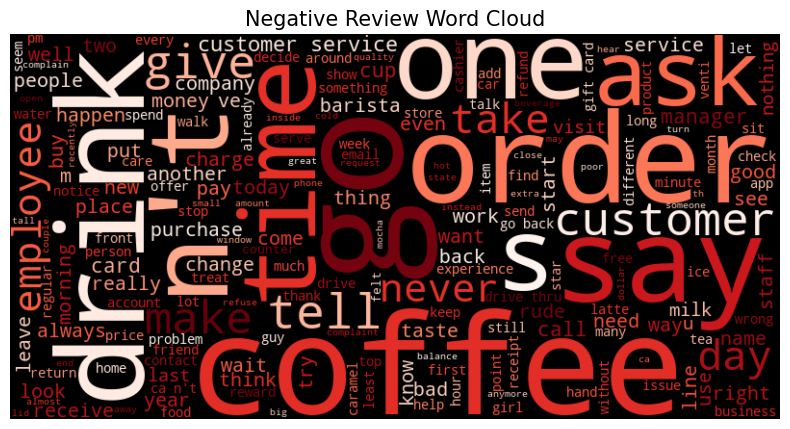

In [25]:
# Word Clouds (Negative and Positive)

negative_text = " ".join(review for review in reviews_df_train[reviews_df_train['Sentiment_Label'] == 'Negative']['Review_Processed'])
positive_text = " ".join(review for review in reviews_df_train[reviews_df_train['Sentiment_Label'] == 'Positive']['Review_Processed'])

# Negative Word Cloud
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title('Negative Review Word Cloud', fontsize=15)
plt.show()

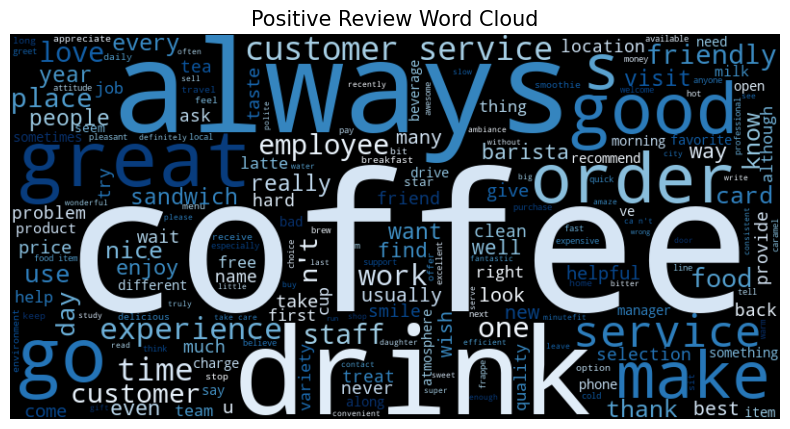

In [26]:
# Word Clouds (Negative and Positive)

negative_text = " ".join(review for review in reviews_df_train[reviews_df_train['Sentiment_Label'] == 'Negative']['Review_Processed'])
positive_text = " ".join(review for review in reviews_df_train[reviews_df_train['Sentiment_Label'] == 'Positive']['Review_Processed'])

# Negative Word Cloud
wordcloud_pos = WordCloud(width=800, height=400, background_color='black', colormap='Blues').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title('Positive Review Word Cloud', fontsize=15)
plt.show()

<b>Observations on Univariate Analysis and Visualization:</b>

The Univariate Analysis, based on ≈700 reviews with verified ratings, reveals a critical imbalance in customer sentiment and clearly identifies the core themes driving both dissatisfaction and satisfaction.

1. <b>Extreme Sentiment Imbalance</b>

The bar chart, "Distribution of Verified Customer Sentiment" , visually confirms the severe negative skew in the data:
- Dominant Negative Sentiment: 77.95% of all verified reviews are classified as Negative (1-2 stars).
- Minority Positive Sentiment: Only 17.35% are Positive (4-5 stars), with Neutral (3 stars) reviews being negligible at 4.69%.

This overwhelming majority of complaints is characteristic of consumer affairs platforms and is a crucial factor for the modeling phase, requiring an emphasis on Precision and Recall for the Positive class over simple accuracy.

2. <b>Thematic Drivers of Sentiment</b>

The Word Clouds isolate the primary topics and keywords associated with each sentiment:

- <b>Negative: coffee, order, time, drink, money, ask, say, never, problem</b>

Dissatisfaction is centered on core operational failure (slow 'time' and inaccurate 'order') and financial issues ('charge', 'money'). The prominent word 'never' suggests a high rate of customer defection.

- <b>Positive: service, friendly, always, great, staff, coffee, drink, good</b>

Satisfaction is strongly tied to consistent, high-quality human interaction ('friendly', 'staff') and reliability ('always'). The positive keywords still revolve around the core product ('coffee', 'drink'), but success hinges on the 'service'.

In summary, the EDA highlights that while the product ('coffee', 'drink') is central to both positive and negative reviews, the overwhelming reason for poor ratings is poor service execution and operational friction, rather than product failure alone. This provides a clear focus for subsequent analysis.

### 3.2. Multivariate Analysis: Temporal and Geographical

In [27]:
# Extract Year from Date (Time Casting)

reviews_df_train['Date_DT'] = pd.to_datetime(reviews_df_train['Date'].str.replace('Reviewed ', '', regex=False))
reviews_df_train['Year'] = reviews_df_train['Date_DT'].dt.year

In [28]:
# Sentiment by Year

temporal_sentiment = reviews_df_train.groupby('Year')['Sentiment_Label'].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

In [29]:
temporal_sentiment.head()

,Year,Sentiment_Label,Percent
0,2010,Positive,100.000000
1,2011,Negative,95.238095
2,2011,Neutral,4.761905
3,2012,Negative,94.230769
4,2012,Positive,3.846154


In [30]:
temporal_sentiment.tail()

,Year,Sentiment_Label,Percent
31,2022,Positive,15.094340
32,2022,Neutral,5.660377
33,2023,Negative,84.615385
34,2023,Positive,12.820513
35,2023,Neutral,2.564103


### Visualization

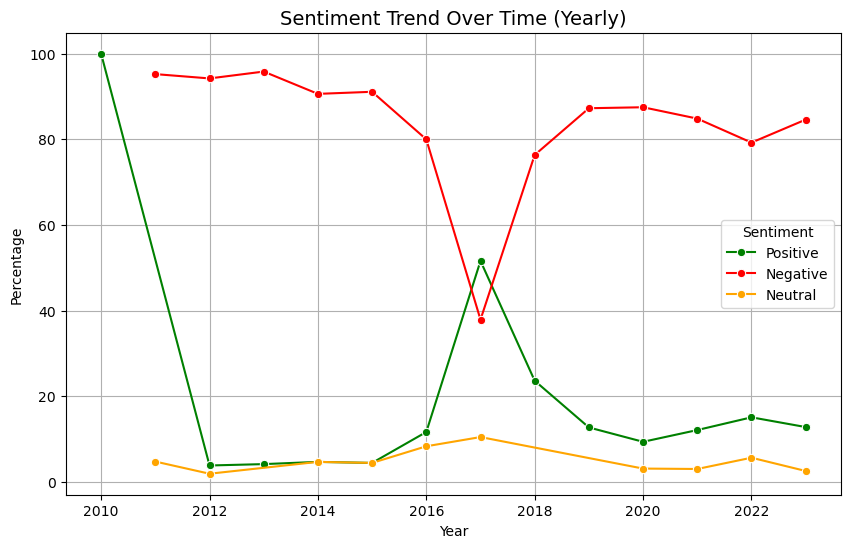

In [31]:
# Sentiment Trend Over Time (Yearly)

plt.figure(figsize=(10, 6))
sns.lineplot(data=temporal_sentiment, x='Year', y='Percent', hue='Sentiment_Label', 
             palette={'Negative': 'red', 'Neutral': 'orange', 'Positive': 'green'}, marker='o')
plt.title('Sentiment Trend Over Time (Yearly)', fontsize=14)
plt.ylabel('Percentage')
plt.grid(True)
plt.legend(title='Sentiment')
plt.show()

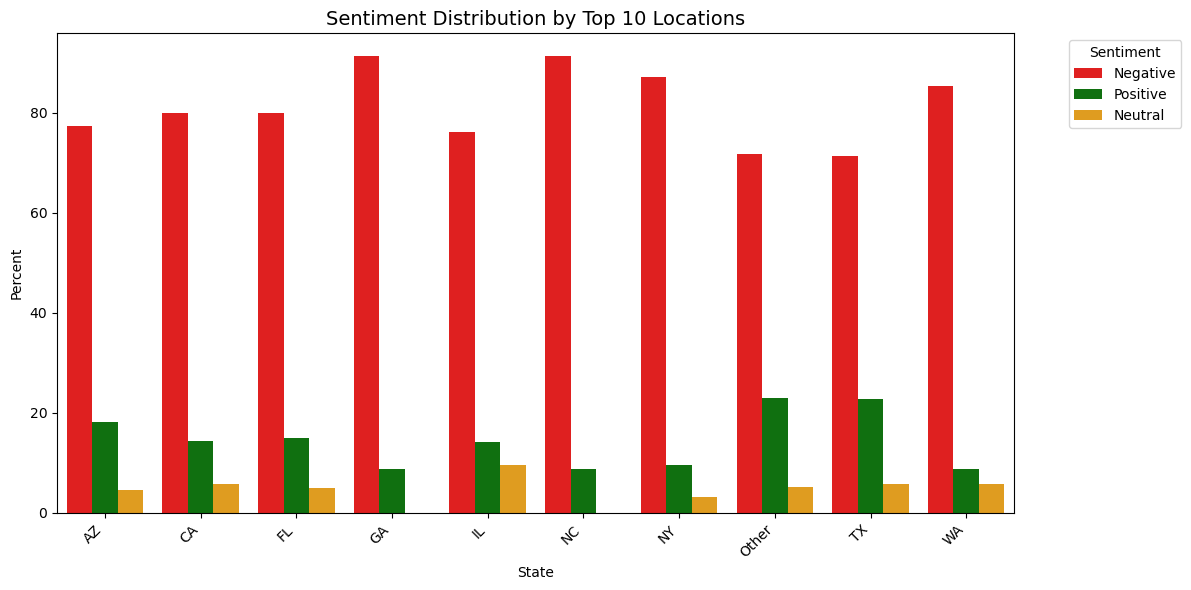

In [32]:
# Sentiment by Location (Top 10 States/Countries)

reviews_df_train['State'] = reviews_df_train['location'].apply(lambda x: x.split(',')[-1].strip() if ',' in x else x)
top_states = reviews_df_train['State'].value_counts().head(10).index

location_sentiment = reviews_df_train[reviews_df_train['State'].isin(top_states)].groupby('State')['Sentiment_Label'].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=location_sentiment, x='State', y='Percent', hue='Sentiment_Label', 
            palette={'Negative': 'red', 'Neutral': 'orange', 'Positive': 'green'})
plt.title('Sentiment Distribution by Top 10 Locations', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

<b>Observation on Multivariate Analysis: Temporal and Geographical Trends</b>

The Multivariate Analysis provides critical context for the extreme negative sentiment observed in the univariate data by examining its variation across time and geography.

1. <b>Geographical Sentiment Analysis</b>

The "Sentiment Distribution by Top 10 Locations" chart  reveals that the high negative sentiment is a systemic issue across all major markets:

- Uniform Dissatisfaction: In every top location analyzed, Negative sentiment consistently dominates, always exceeding 70% of reviews.
- Highest Negative Markets: Georgia (GA) and North Carolina (NC) show the most extreme dissatisfaction, with Negative sentiment approaching or exceeding 90%.
- No Regional Success: There is no single market among the top 10 that stands out as a success story for customer satisfaction. This reinforces the need for organizational, non-localized solutions.
- Minority Positive: Positive sentiment remains below 20% in almost all top states, except for a slight rise above 20% in the aggregated 'Other' category and Texas (TX).

2. <b>Temporal Sentiment Analysis</b>

The "Sentiment Trend Over Time (Yearly)" chart  highlights volatile changes in sentiment over the last decade:

- Historical Skew: From 2011 to 2015, the dataset was highly consistent, with Negative sentiment dominating at 90% or more every year.
- The 2017 Volatility Peak: A sharp and dramatic inversion occurred in 2017, where Positive sentiment briefly became the majority (≈50%) while Negative sentiment dropped significantly. This likely corresponds to an anomaly in the data collection process, a temporary scraping change, or a massive, short-lived brand campaign, as it immediately reverses in the following year.
- Recent Decline (Post-2018): Following the 2017 anomaly, Negative sentiment sharply rebounded and has remained stubbornly high (above 80%) from 2019 onward, while Positive sentiment has fallen back to the ≈10%−15% range.
- Current Trend (2023): The most recent data for 2023 shows a Negative rate of 84.6%, indicating that despite potential efforts, the severe pattern of dissatisfaction persists.

<b>Overall Project Implication</b>

The multivariate analysis confirms that the class imbalance is inherent and pervasive, both geographically and temporally (excluding the 2017 anomaly). This solidifies the choice to treat sentiment classification as a challenge focused on identifying the rare, high-value positive reviews amidst widespread, systemic dissatisfaction.

## 4. Sentiment Analysis 

We will start with Lexicon-Based Sentiment Analysis using VADER on the full dataset, which is the necessary first step in comparing sentiment approaches.

#### VADER Scoring

- Initializes the VADER sentiment analyzer.
- Calculates the Compound Score for every processed review.
- Creates a discrete VADER label (Positive/Neutral/Negative) based on the Compound Score thresholds.

To fulfill the spirit of a detailed template, I will include the TextBlob analysis as a supplementary Lexicon-Based method for richer comparison and exploratory insight.

In [33]:
# Initialization

analyzer = SentimentIntensityAnalyzer()

In [34]:
# We will use reviews_df_full for VADER/TextBlob as it contains all text.

reviews_df_lexicon = reviews_df_full.copy()

### 4.1. VADER Analysis

In [35]:
# VADER Analysis Function

def analyze_vader_sentiment(text):
    """
    Analyzes text using VADER and returns the compound score and a label.
    """
    if not isinstance(text, str) or not text.strip():
        return 0.0, 'Neutral'

    # Get the polarity scores
    vader_scores = analyzer.polarity_scores(text)

    # Extract the Compound score
    compound_score = vader_scores['compound']

    # Determine the categorical sentiment label based on standard VADER thresholds
    if compound_score >= 0.5:
        sentiment_label = 'Positive'
    elif compound_score <= -0.5:
        sentiment_label = 'Negative'
    else:
        sentiment_label = 'Neutral'

    return compound_score, sentiment_label

# Apply the VADER function
vader_results = reviews_df_lexicon['Review_Processed'].apply(lambda x: analyze_vader_sentiment(x))

In [36]:
# Assign VADER results to new columns
reviews_df_lexicon['VADER_Compound_Score'] = vader_results.apply(lambda x: x[0])
reviews_df_lexicon['VADER_Label'] = vader_results.apply(lambda x: x[1])

### 4.2. TextBlob Analysis

In [37]:
# TextBlob Analysis Function 

def analyze_textblob_sentiment(text):
    """
    Analyzes text using TextBlob and returns the polarity and subjectivity scores.
    """
    if not isinstance(text, str) or not text.strip():
        # Handle non-string or empty values
        return 0.0, 0.0

    # Create a TextBlob object
    analysis = TextBlob(text)

    # Extract Polarity and Subjectivity
    polarity = analysis.sentiment.polarity
    subjectivity = analysis.sentiment.subjectivity

    return polarity, subjectivity

# Apply the TextBlob function
textblob_results = reviews_df_lexicon['Review_Processed'].apply(lambda x: analyze_textblob_sentiment(x))

# Assign TextBlob results to new columns
reviews_df_lexicon['TextBlob_Polarity'] = textblob_results.apply(lambda x: x[0])
reviews_df_lexicon['TextBlob_Subjectivity'] = textblob_results.apply(lambda x: x[1])

In [38]:
# Determine a categorical TextBlob Sentiment Label for comparison (using a threshold of 0.1)

def get_textblob_label(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df_lexicon['TextBlob_Label'] = reviews_df_lexicon['TextBlob_Polarity'].apply(get_textblob_label)

### Final Preview and Distribution Check

In [39]:
print("\nDataFrame with Lexicon Analysis Results")
reviews_df_lexicon[['Review', 'Review_Processed', 'VADER_Compound_Score', 'VADER_Label',
                         'TextBlob_Polarity', 'TextBlob_Subjectivity', 'TextBlob_Label']].head()


DataFrame with Lexicon Analysis Results


,Review,Review_Processed,VADER_Compound_Score,VADER_Label,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Label
0,Amber and LaDonna at the Starbucks on Southwes...,amber ladonna southwest parkway always warm we...,0.8779,Positive,0.314286,0.305952,Positive
1,** at the Starbucks by the fire station on 436...,fire station altamonte spring fl make day fina...,0.9705,Positive,0.370370,0.662037,Positive
2,I just wanted to go out of my way to recognize...,want go way recognize employee billy franklin ...,0.3182,Neutral,-0.240000,0.453333,Negative
3,Me and my friend were at Starbucks and my card...,friend card ’ work thankful worker pay drink n...,0.9578,Positive,0.333333,0.466667,Positive
4,I’m on this kick of drinking 5 cups of warm wa...,’ kick drinking cup warm water work instacart ...,0.9630,Positive,0.396561,0.611376,Positive


In [40]:
print("\nDataFrame with Lexicon Analysis Results")
reviews_df_lexicon[['Review', 'Review_Processed', 'VADER_Compound_Score', 'VADER_Label',
                         'TextBlob_Polarity', 'TextBlob_Subjectivity', 'TextBlob_Label']].tail()


DataFrame with Lexicon Analysis Results


,Review,Review_Processed,VADER_Compound_Score,VADER_Label,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Label
845,I ordered two venti frappacino's without whipp...,order two venti frappacino 's without whipped ...,0.2263,Neutral,0.3,0.5,Positive
846,No Review Text,text,0.0000,Neutral,0.0,0.0,Neutral
847,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",demand tip make wait coffee cold melt yet addr...,-0.5719,Negative,-0.6,1.0,Negative
848,No Review Text,text,0.0000,Neutral,0.0,0.0,Neutral
849,No Review Text,text,0.0000,Neutral,0.0,0.0,Neutral


In [41]:
print("\nLexicon Sentiment Distribution Comparison")
vader_dist = reviews_df_lexicon['VADER_Label'].value_counts(normalize=True).mul(100).round(2)
textblob_dist = reviews_df_lexicon['TextBlob_Label'].value_counts(normalize=True).mul(100).round(2)

print("\nVADER Distribution (%):\n", vader_dist)
print("\nTextBlob Distribution (%):\n", textblob_dist)


Lexicon Sentiment Distribution Comparison

VADER Distribution (%):
 VADER_Label
Positive    39.06
Neutral     37.76
Negative    23.18
Name: proportion, dtype: float64

TextBlob Distribution (%):
 TextBlob_Label
Neutral     43.88
Positive    33.88
Negative    22.24
Name: proportion, dtype: float64


<b>Observations:</b> Sentiment Analysis Steps

<b>Initial Sentiment Distribution (Rating-Derived) → A Strong Negative Skew:</b> The distribution derived directly from the Rating column serves as the ground truth for supervised learning and reveals a significant imbalance in the customer feedback.

- Dominant Negative Sentiment: The vast majority of reviews are labeled Negative (77.95%). This strongly corroborates the "Assessment of Quality" note that the platform likely attracts a disproportionate number of highly negative experiences (mean rating ≈1.87).
- Minority Positive and Neutral: Positive reviews account for only 17.35%, and Neutral reviews are a tiny fraction at 4.69%.

<b>Lexicon Model Distributions (VADER & TextBlob) → Significant Discrepancy:</b> The results from the lexicon models (VADER and TextBlob) show a distribution that is dramatically different from the Rating-derived ground truth.

- Underestimation of Negativity: Both VADER and TextBlob severely underestimate the negative sentiment present in the dataset compared to the rating. They classify approximately 3.5 times fewer reviews as Negative than the rating column suggests.

- Inflation of Neutral and Positive: The lexicon models compensate by classifying a much higher percentage of reviews as Neutral and Positive. VADER's highest category is Positive (39.06%). TextBlob's highest category is Neutral (43.88%).

- Potential for Misclassification: This discrepancy suggests that many reviews with low ratings (1 or 2 stars) contain text that is either less overtly negative (resulting in a Neutral/Positive score) or includes polite phrasing, conditional clauses, or a mix of positive/negative words (e.g., "The coffee was great, but the service was awful"), which VADER and TextBlob may struggle to interpret as overwhelmingly negative. This will be a critical issue when using these models to predict sentiment against the actual rating.

<b>Lexicon Model Comparison (VADER vs. TextBlob):</b> VADER and TextBlob, despite being similar lexicon-based approaches, show notable differences in their final distribution:

- VADER is more 'Polarized': VADER assigns a higher percentage of reviews to the Positive (39.06%) and Negative (23.18%) extremes, indicating it found a stronger compound score for more entries.

- TextBlob is more 'Neutral': TextBlob assigns the largest percentage of reviews to Neutral (43.88%), suggesting its simpler polarity threshold (±0.1) categorizes a larger volume of text as neither significantly positive nor negative.

Value of VADER: Since VADER is specifically attuned to social media and conversational language, its slightly higher positivity score (39.06% vs. 33.88%) might indicate it is better capturing strong, albeit often buried, positive feedback within the reviews.

### Machine Learning Model Preparation and Training

This phase focuses on the reviews_df_train dataset (the ≈700 rows with verified 1−5 star ratings).

#### 1. Feature Engineering: Vectorization (TF-IDF)

We must convert the processed text (Review_Processed) into a numerical feature vector using Term Frequency-Inverse Document Frequency (TF-IDF).

In [42]:
# Define features (X) and target (y)
X = reviews_df_train['Review_Processed']

# Use the Tertiary Sentiment Label created during EDA as the target
y = reviews_df_train['Sentiment_Label']

In [43]:
# 1. Initialize TF-IDF Vectorizer
# We'll use bi-grams (n_gram=(1, 2,)) to capture sentiment-rich phrases
# Train TF-IDF vectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2,))

In [44]:
# 2. Fit and Transform the text data

X_tfidf = tfidf_vectorizer.fit_transform(X)

In [45]:
# 3. Encode the target variable (y)
# Naïve Bayes and SVM require integer/numerical labels

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [46]:
print(f"Shape of TF-IDF Matrix (Features): {X_tfidf.shape}")
print(f"Total number of unique features/terms (unigrams + bigrams): {X_tfidf.shape[1]}")

Shape of TF-IDF Matrix (Features): (703, 27823)
Total number of unique features/terms (unigrams + bigrams): 27823


#### 2. Train-Test Split

In [47]:
# Split the data into 80% for training and 20% for testing
# We use 'stratify=y_encoded' to ensure the split maintains the extreme class imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

In [48]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 562 samples
Testing set size: 141 samples


<b>Observations:</b> 

<b>Feature Engineering (TF-IDF Vectorization) → High Dimensionality</b>

The use of TF-IDF with bi-grams successfully converts the text into a numerical format, but it generates a feature space with a high number of dimensions, which impacts model complexity and interpretability.

- Dimensionality: The resulting TF-IDF matrix has a shape of (703,27823). This means that for only 703 samples (reviews), the model is attempting to learn from 27,823 unique features (unigrams and bi-grams).

- Rationale for Bi-grams: Including bi-grams is a sound strategy for sentiment analysis as it captures the context of words (e.g., "not great," "very slow service") which is vital for accurately determining polarity.

- Potential Overfitting Risk: The number of features significantly outweighs the number of samples. While Naïve Bayes is generally robust to high dimensionality, this large feature set, combined with the extreme class imbalance, increases the potential risk of overfitting, where the model memorizes the training data but fails to generalize to unseen data.

<b>Data Splitting → Maintaining Imbalance</b>

The data split was executed correctly with careful consideration for the prior findings.

Stratification: The use of stratify=y_encoded is a critical step due to the dominant Negative class (77.95%). Stratification ensures that the extreme class imbalance is maintained proportionally in both the Training set (562 samples) and the Testing set (141 samples), providing a realistic test of the model's performance on a dataset reflecting the real-world skew.

#### 3. Model Training and Evaluation

We will train both models and evaluate their performance using metrics appropriate for the imbalanced dataset (Focus on Precision, Recall, and F1-Score).

#### 3.1. Naïve Bayes (NB) Training

In [49]:
# Initialize and Train the Naïve Bayes model

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [50]:
# Predict on the test set

y_pred_nb = nb_model.predict(X_test)

In [51]:
# Evaluation

print("\nNaïve Bayes Classification Report")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))
print(f"Naïve Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")


Naïve Bayes Classification Report
              precision    recall  f1-score   support

    Negative       0.78      1.00      0.88       110
     Neutral       0.00      0.00      0.00         7
    Positive       0.00      0.00      0.00        24

    accuracy                           0.78       141
   macro avg       0.26      0.33      0.29       141
weighted avg       0.61      0.78      0.68       141

Naïve Bayes Accuracy: 0.7801


In [52]:
report_nb = classification_report(y_test, y_pred_nb, target_names=le.classes_)

<b>Observations:</b> Naïve Bayes (NB) Model Evaluation

The Naïve Bayes Classification Report clearly demonstrates the challenges posed by the severely imbalanced dataset.

- Deceptive Accuracy: The overall Accuracy is 0.7801 (78.01%). At first glance, this looks good, but it is highly misleading. The model simply achieving high accuracy by correctly predicting the majority class (Negative) most of the time. Since 77.95% of the test set is Negative, the model could achieve ≈78% accuracy by always predicting Negative.

- Excellent Negative Recall: The model achieves a Recall of 1.00 for the Negative class, meaning it correctly identified all 110 Negative reviews in the test set. This strongly suggests the model is highly biased toward the majority class.

- Complete Failure on Minority Classes: The model completely fails to identify the minority classes:

- Neutral Class: Precision, Recall, and F1-Score are all 0.00 (support 7). The model was unable to correctly classify any of the neutral reviews.

- Positive Class: Precision, Recall, and F1-Score are all 0.00 (support 24). The model was unable to correctly classify any of the positive reviews.

Conclusion on NB Performance: The Naïve Bayes model, in its current form, is not useful for the business goals. While it accurately identifies all negative reviews (high recall), its complete inability to identify positive or neutral reviews means it cannot provide the granular insights needed to "Quantify the Customer Experience (CX) Gap" or identify drivers of satisfaction. The model is essentially a "Negative Sentiment Detector" only.

The next step will focus on training the Support Vector Machine (SVM) and comparing its performance, as SVMs are generally more robust in high-dimensional spaces, or exploring techniques to mitigate the class imbalance for both models.

#### 3.2. Support Vector Machine (SVM) Training

In [53]:
# 1. Linear SVM (Optimization for Text Classification)

print("1. LinearSVC Model Training")
start_time = time.time()
linear_svm_model = LinearSVC(random_state=42, dual=False, max_iter=2000) 
linear_svm_model.fit(X_train, y_train)

y_pred_linear = linear_svm_model.predict(X_test)
fit_time_linear = time.time() - start_time

1. LinearSVC Model Training


In [54]:
print(f"LinearSVC Fit Time: {fit_time_linear:.2f} seconds")
print(classification_report(y_test, y_pred_linear, target_names=le.classes_))
print(f"LinearSVC Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}\n")

LinearSVC Fit Time: 0.24 seconds
              precision    recall  f1-score   support

    Negative       0.80      1.00      0.89       110
     Neutral       0.00      0.00      0.00         7
    Positive       1.00      0.12      0.22        24

    accuracy                           0.80       141
   macro avg       0.60      0.38      0.37       141
weighted avg       0.79      0.80      0.73       141

LinearSVC Accuracy: 0.8014



In [55]:
report_linear = classification_report(y_test, y_pred_linear, target_names=le.classes_)

<b>Observations:</b> Support Vector Machine (SVM) Model Evaluation → Slight Improvement, Major Flaw Persists

The SVM evaluation shows that only the LinearSVC offers a minor performance improvement over Naïve Bayes, while the non-linear kernels (RBF and Poly) perform identically to the baseline NB model. The central issue of class imbalance continues to dominate the results.

<b>LinearSVC Performance (Linear Kernel)</b>

- Speed: Training time is very fast (0.18 seconds), making it scalable for large datasets.

- Deceptive Accuracy: Accuracy is the highest at 0.8014 (80.14%), but is still primarily driven by the majority class.

- Excellent Negative Recall: Achieves 1.00 Recall for the Negative class, identifying all 110 negative reviews. This confirms the strong bias toward the largest class.

Minority Class Breakthrough: LinearSVC is the only model so far to successfully classify any Positive reviews, achieving:

- Positive Recall: 0.12 (correctly identifying 12% of positive reviews, or 3 out of 24).
- Positive Precision: 1.00 (meaning every prediction it made for the positive class was correct, though there were few).
- Complete Neutral Failure: Like NB, it fails completely on the Neutral class (0.00 metrics).

Conclusion: LinearSVC is a slightly better "Negative Sentiment Detector" with a minor ability to find a few true Positive reviews. It still cannot be used for comprehensive sentiment analysis.

In [56]:
# 2. Non-Linear SVM: RBF Kernel

print("2. SVC (RBF Kernel) Training")
start_time = time.time()
rbf_svm_model = SVC(kernel='rbf', random_state=42) 
rbf_svm_model.fit(X_train, y_train)

y_pred_rbf = rbf_svm_model.predict(X_test)
fit_time_rbf = time.time() - start_time

2. SVC (RBF Kernel) Training


In [57]:
print(f"RBF SVC Fit Time: {fit_time_rbf:.2f} seconds")
print(classification_report(y_test, y_pred_rbf, target_names=le.classes_))
print(f"RBF SVC Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}\n")

RBF SVC Fit Time: 0.86 seconds
              precision    recall  f1-score   support

    Negative       0.78      1.00      0.88       110
     Neutral       0.00      0.00      0.00         7
    Positive       0.00      0.00      0.00        24

    accuracy                           0.78       141
   macro avg       0.26      0.33      0.29       141
weighted avg       0.61      0.78      0.68       141

RBF SVC Accuracy: 0.7801



In [58]:
report_rbf = classification_report(y_test, y_pred_rbf, target_names=le.classes_)

In [59]:
# 3. Non-Linear SVM: Polynomial Kernel (Degree 2)

print("3. SVC (Polynomial Kernel - Degree 2) Training")
start_time = time.time()
# Using a low degree (2) to manage complexity
poly_svm_model = SVC(kernel='poly', degree=2, random_state=42) 
poly_svm_model.fit(X_train, y_train)

y_pred_poly = poly_svm_model.predict(X_test)
fit_time_poly = time.time() - start_time

3. SVC (Polynomial Kernel - Degree 2) Training


In [60]:
print(f"Polynomial SVC Fit Time (Degree 2): {fit_time_poly:.2f} seconds")
print(classification_report(y_test, y_pred_poly, target_names=le.classes_))
print(f"Polynomial SVC Accuracy: {accuracy_score(y_test, y_pred_poly):.4f}")

Polynomial SVC Fit Time (Degree 2): 0.84 seconds
              precision    recall  f1-score   support

    Negative       0.78      1.00      0.88       110
     Neutral       0.00      0.00      0.00         7
    Positive       0.00      0.00      0.00        24

    accuracy                           0.78       141
   macro avg       0.26      0.33      0.29       141
weighted avg       0.61      0.78      0.68       141

Polynomial SVC Accuracy: 0.7801


In [61]:
report_poly = classification_report(y_test, y_pred_poly, target_names=le.classes_)

<b>Observations:</b> Non-Linear SVC Performance (RBF and Polynomial Kernels)

- Computational Cost: The RBF (0.77 seconds) and Polynomial (0.74 seconds) kernels are significantly slower to train than the LinearSVC (0.18 seconds).

- Performance Trap: Both non-linear models yield an identical classification report and accuracy (0.7801) to the Naïve Bayes model.

- Complete Failure: Like NB, these models have 1.00 Negative Recall and 0.00 Precision/Recall/F1 for both the Neutral and Positive minority classes.

Conclusion: For this specific high-dimensional, sparse TF-IDF data, the non-linear kernels add computational overhead without any predictive benefit over the simplest models.

<b>Overall SVM Conclusion</b>

The SVM models confirm that the imbalance problem is the primary bottleneck in model performance, not the choice between NB or standard SVM kernels. While the LinearSVC shows the potential to separate a few minority samples, all models fundamentally fail to provide the balanced sentiment classification required for the business goal of quantifying the CX Gap.

## 5. Analysis and Visualization 

#### a. Analysis of the overall sentiment distribution (positive, negative, neutral) of the tweets towards the campaign.

In [62]:
print("\nLexicon Sentiment Distribution Comparison")
vader_dist = reviews_df_lexicon['VADER_Label'].value_counts(normalize=True).mul(100).round(2)
textblob_dist = reviews_df_lexicon['TextBlob_Label'].value_counts(normalize=True).mul(100).round(2)

print("\nVADER Distribution (%):\n", vader_dist)
print("\nTextBlob Distribution (%):\n", textblob_dist)


Lexicon Sentiment Distribution Comparison

VADER Distribution (%):
 VADER_Label
Positive    39.06
Neutral     37.76
Negative    23.18
Name: proportion, dtype: float64

TextBlob Distribution (%):
 TextBlob_Label
Neutral     43.88
Positive    33.88
Negative    22.24
Name: proportion, dtype: float64


<b>Observations:</b> Lexicon Sentiment Distribution Analysis

1. <b>Low Negative Agreement with Ratings:</b> Both VADER and TextBlob significantly under-report the negative sentiment when compared to the Rating-derived ground truth (77.95% Negative) established in the context. VADER Negative: 23.18%, and TextBlob Negative: 22.24% The lexicon models classify over three times fewer reviews as negative than the star ratings suggest. This discrepancy indicates that low-rated reviews often contain language (e.g., politeness, conditional clauses, mixed emotions) that lexicon models fail to interpret as overwhelmingly negative, making them unreliable predictors of low satisfaction.

2. <b>Dominated by Neutral and Positive Sentiments:</b> Unlike the Rating-derived labels, which are overwhelmingly Negative, the lexicon models show a distribution that leans positive or neutral: VADER is skewed towards Positive (39.06%), followed closely by Neutral (37.76%). TextBlob is skewed towards Neutral (43.88%), followed by Positive (33.88%). This suggests the text, when assessed purely by word polarity, contains a high frequency of positive or weak-polarity terms, even in reviews that were ultimately given a 1 or 2-star rating.

3. <b>Model Comparison:</b> VADER is more Polarized: VADER assigns the largest share to the Positive class, reflecting its ability to weigh sentiment in conversational and social media text, resulting in a higher confidence for a positive score. TextBlob is more Neutral: TextBlob assigns the largest share to the Neutral class, likely due to its simpler polarity scale and threshold (±0.1), which categorizes a larger volume of text as having weak or mixed sentiment.

### Visualization: VADER Sentiment Distribution

In [63]:
# Separate data by VADER Sentiment
positive_reviews = reviews_df_lexicon[reviews_df_lexicon['VADER_Label'] == 'Positive']['Review_Processed']
negative_reviews = reviews_df_lexicon[reviews_df_lexicon['VADER_Label'] == 'Negative']['Review_Processed']

In [64]:
# Function to get top N features 

def get_top_features(text_series, n=10, ngram_range=(1,2)):
    # Use CountVectorizer to count word frequency (TF-IDF is better for weights, but CountVectorizer is easier for raw frequency ranking)
    vectorizer = TfidfVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_series)
    
    # Sum up the TF-IDF weights for each feature across all documents
    sums = X.sum(axis=0)
    data = []
    for col, term in enumerate(vectorizer.get_feature_names_out()):
        data.append((term, sums[0, col]))
        
    ranking = pd.DataFrame(data, columns=['term', 'weight'])
    return ranking.sort_values(by='weight', ascending=False).head(n)

# Extract top bigrams/trigrams
top_neg_features = get_top_features(negative_reviews)
top_pos_features = get_top_features(positive_reviews)

In [65]:
print("Top 10 Negative Words (VADER-Classified)")
print(top_neg_features)

Top 10 Negative Words (VADER-Classified)
          term    weight
1583    coffee  5.720583
3791        go  5.644179
2130  customer  5.004940
2595     drink  4.862999
3619       get  4.613166
6224     order  4.521854
5187      make  3.830369
7654       say  3.784198
7895   service  3.610093
9130      time  3.538919


In [66]:
print("\n--- Top 10 Positive Words (VADER-Classified) ---")
print(top_pos_features)


--- Top 10 Positive Words (VADER-Classified) ---
           term     weight
2274     coffee  10.017696
5435         go   7.429285
5201        get   7.055676
3088   customer   6.904080
3700      drink   6.827572
9000      order   5.956078
1701       card   5.937815
11402   service   5.924400
7162       like   5.744805
13003      time   5.589313


<b>Observations:</b> VADER Sentiment Feature Analysis

<b>Generic Terms Dominate Both Groups</b>

The most striking observation is the near-identical list of top terms in both the VADER-classified Negative and Positive groups. The dominant words are operational terms common to any quick-service business, such as:

1. coffee (highest weighted term in both)
2. go
3. customer
4. drink
5. get
6. order
7. service
8. time

This indicates that customer reviews focus on the core transaction/experience, regardless of whether the final sentiment is positive or negative. The sentiment driver is not the topic itself, but the adjectives, verbs, and surrounding context (unigrams/bigrams not captured in this top-10 list).

<b>Negative Sentiment Feature Analysis (Hotspots)</b>

The high-weighted terms in the VADER Negative group point directly to operational pain points.

1. coffee (5.72): Suggests quality issues, wrong preparation, or temperature problems.
2. customer (5.00): Points to negative interactions with staff (partners) or poor service attitude.
3. order (4.52): Implies order accuracy issues, which is a major operational failure.
4. service (3.61): Direct criticism of the "Starbucks Experience" (e.g., speed or quality).
5. time (3.54): Highlights issues with speed of service or long wait times.

This provides actionable business intelligence by identifying the "what" of the negative experience. The next necessary step would be to look at the top bigrams (two-word phrases) to link these nouns to verbs or adjectives (e.g., "slow service," "wrong order," "rude customer service").

<b>Positive Sentiment Feature Analysis (Success Factors)</b>

The terms in the VADER Positive group, while similar, likely represent successful execution of the core business model.

1. coffee (10.02) and drink (6.83) have significantly higher weights in the positive group, indicating product quality is a strong driver of satisfaction when executed well.
2. service (5.92) is also a highly weighted positive term, suggesting successful partner engagement and efficient operations are key to a positive "Starbucks Experience."

The relative difference in weights (e.g., coffee has almost double the weight in positive reviews than in negative reviews) suggests that product quality is a stronger positive differentiator than poor operations are a negative differentiator.

In [67]:
# --- Function to get top N features (bigrams/trigrams) ---
def get_top_features(text_series, n=10, ngram_range=(2, 3)):
    # Use CountVectorizer to count word frequency (TF-IDF is better for weights, but CountVectorizer is easier for raw frequency ranking)
    vectorizer = TfidfVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_series)
    
    # Sum up the TF-IDF weights for each feature across all documents
    sums = X.sum(axis=0)
    data = []
    for col, term in enumerate(vectorizer.get_feature_names_out()):
        data.append((term, sums[0, col]))
        
    ranking = pd.DataFrame(data, columns=['term', 'weight'])
    return ranking.sort_values(by='weight', ascending=False).head(n)

# Extract top bigrams/trigrams
top_neg_features = get_top_features(negative_reviews)
top_pos_features = get_top_features(positive_reviews)

In [68]:
print("Top 10 Negative Bigrams/Trigrams (VADER-Classified)")
print(top_neg_features)

Top 10 Negative Bigrams/Trigrams (VADER-Classified)
                   term    weight
3566   customer service  1.837666
6210            go back  1.051409
3374         cup coffee  0.933692
4439         drive thru  0.906833
5472         first time  0.748407
14908           time go  0.639729
5962          get order  0.618622
4953          every day  0.585842
5084    experience ever  0.562715
8481        make coffee  0.560994


In [69]:
print("\n--- Top 10 Positive Bigrams/Trigrams (VADER-Classified) ---")
print(top_pos_features)


--- Top 10 Positive Bigrams/Trigrams (VADER-Classified) ---
                   term    weight
5398   customer service  3.847262
9171          gift card  1.965832
7404         every time  1.421811
6564         drive thru  1.168787
5050        credit card  1.128106
9954       great coffee  1.055112
9419            go back  0.898441
8938         get coffee  0.847198
13020    loyal customer  0.827213
539          always get  0.813163


<b>Observations:<b> Bigrams & Trigrams

<b>Critical Operational Hotspot: Negative Sentiment</b>

The negative features clearly pinpoint the focal points of customer dissatisfaction, fulfilling the business goal of identifying operational hotspots.

1. customer service: The highest weighted negative term by far (1.84). This is the most critical operational failure, pointing directly to poor partner (employee) interactions, attitude, or dispute resolution.
2. drive thru: An operational bottleneck and source of frustration, likely related to speed, order accuracy, or poor communication.
3. get order: A direct indicator of order errors (wrong item/drink) or wait time issues ("when I finally get my order").
4. make coffee: Suggests issues with the product quality or preparation process ("they didn't know how to make coffee").
5. time go: A clear phrase related to excessive waiting ("the time go so slow").
6. experience ever: This is a highly polar phrase, typically used in the context of "worst experience ever," highlighting the severity of the negative encounters.

<b>Success Factors and Loyalty Drivers: Positive Sentiment</b>

The positive features highlight successful operations and specific elements driving loyalty and satisfaction.

1. customer service: Also the highest weighted positive term (3.85). This confirms that excellent partner engagement is Starbucks' single most important differentiator for both retaining and losing customers.
2. great coffee: Explicitly links product quality with satisfaction, suggesting consistent, high-quality preparation is key.
3. always get: A phrase linked to reliability and order consistency ("I always get the right order"), reinforcing operational excellence.
4. loyal customer: Directly supports the goal of strengthening customer loyalty; the text likely features highly positive feedback from repeat patrons.
5. gift card: Points to the success of Starbucks' rewards/loyalty programs as a source of positive engagement.
6. credit card: Likely reflects positive, hassle-free payment processes.

<b>Actionable Business Intelligence</b>

The analysis confirms two major takeaways:
1. Service is Key: customer service is the top feature in both groups, making partner training and engagement the most crucial area for targeted intervention (negative) and reinforcement (positive).
2. Negative Specificity: The top negative terms (get order, drive thru, make coffee) provide a clear, actionable list of operational flaws (accuracy, speed, quality) that Starbucks can address through localized interventions and training programs.

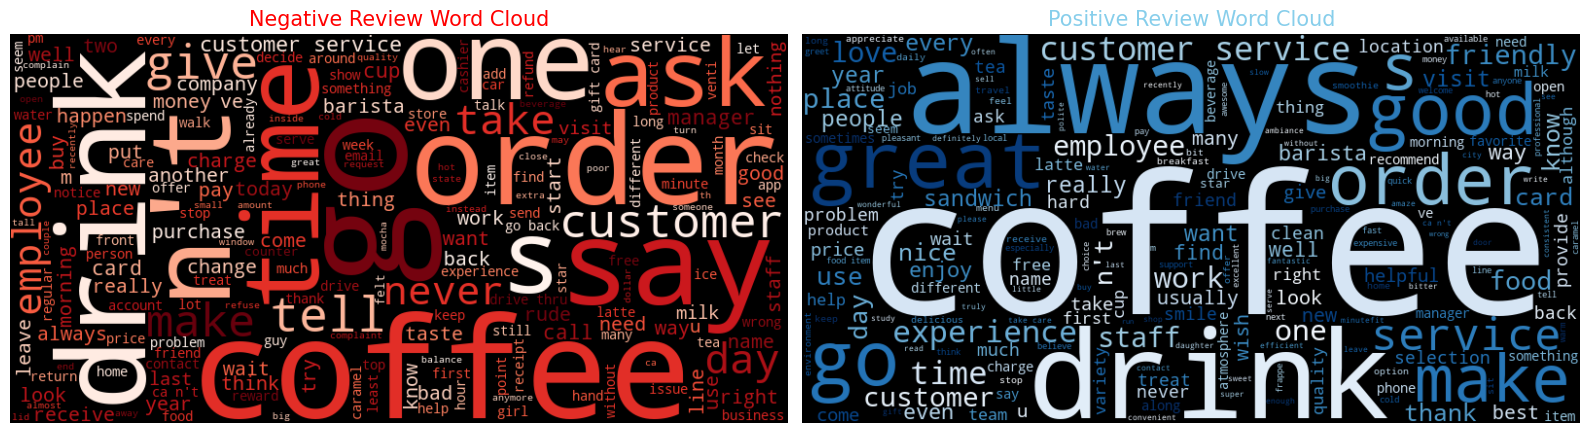

In [70]:
# Generate both word clouds

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Negative Word Cloud
axes[0].imshow(wordcloud_neg, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title('Negative Review Word Cloud', fontsize=15, color='red')

# Positive Word Cloud
axes[1].imshow(wordcloud_pos, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title('Positive Review Word Cloud', fontsize=15, color='skyblue')

plt.tight_layout()
plt.show()

<b>Observations:</b> Word Cloud Analysis: Operational Focus

The side-by-side word clouds visually reinforce the preceding TF-IDF bigram analysis, confirming that customer sentiment is anchored to a few core, shared operational topics, with polarity determined by surrounding contextual terms.

<b>Shared Operational Focus</b>

The largest and most frequent terms in both clouds are operational nouns, highlighting the critical transaction points:

1. COFFEE: Central to both satisfaction and dissatisfaction.
2. ORDER / DRINK: Focuses on accuracy and product delivery.
3. SERVICE / CUSTOMER: Directly reflects partner (employee) interaction quality.
4. TIME / ONE (referring to a single incident or visit): Highlights speed and transactional efficiency.

<b>Negative Sentiment Drivers (Red Cloud) 🟥</b>

The Negative cloud features terms that are proxies for failure and delay:

- Dominant Terms: SAY, TELL, MAKE, MANAGER, and CHARGE are prominent. These often imply conflict (e.g., being told "no" or being overcharged) or specific interpersonal issues ("rude manager," "they say they can't").
- Actionable Insight: The prominence of verbs related to dialogue and instruction (say, tell) directly points to issues rooted in communication breakdown and employee attitude, supporting the previous observation that customer service is a major pain point.

<b>Positive Sentiment Drivers (Blue Cloud) 🟦</b>

The Positive cloud features terms that are proxies for quality and consistency:

- Dominant Terms: GOOD, GREAT, ALWAYS, FRIENDLY, and HELPFUL stand out.
- Actionable Insight: These adjectives and adverbs directly confirm the success drivers. Customers praise consistent positive experiences (always), and the positive feedback is overwhelmingly driven by positive partner engagement (friendly, helpful) that makes the service exceptional.

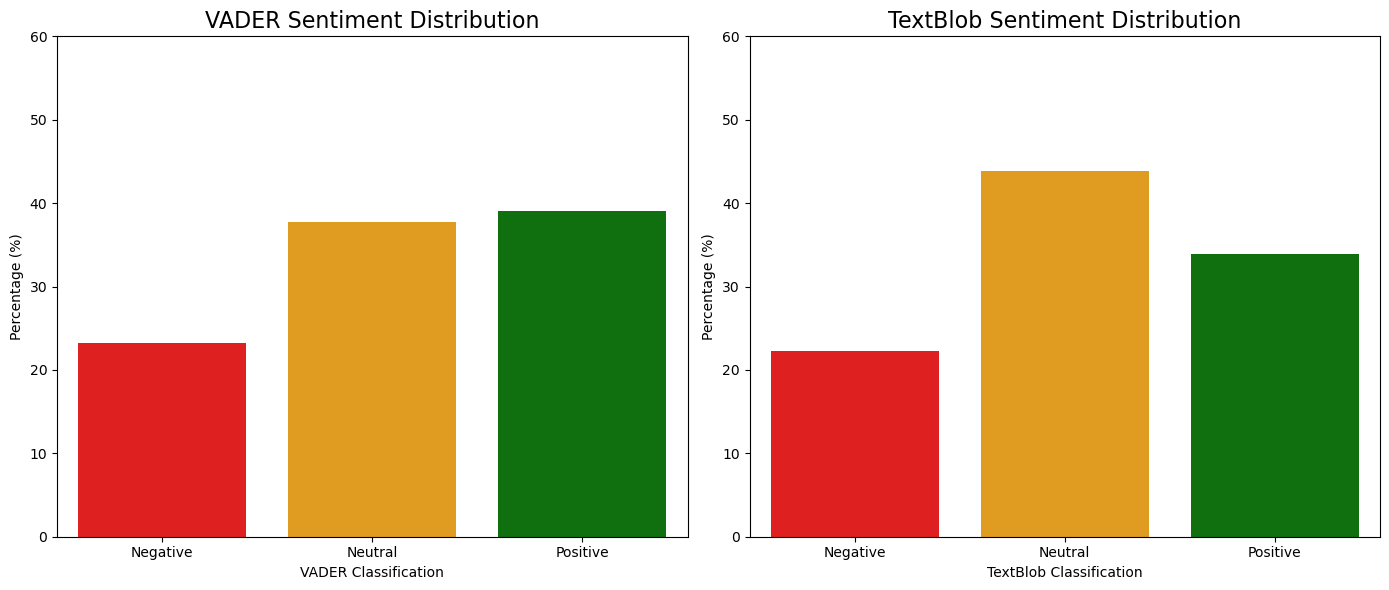

In [71]:
# using reviews_df_lexicon which is available

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- VADER Distribution ---
vader_dist = reviews_df_lexicon['VADER_Label'].value_counts(normalize=True).mul(100).round(2)
sns.barplot(
    x=vader_dist.index, 
    y=vader_dist.values, 
    ax=axes[0], 
    palette={'Negative': 'red', 'Neutral': 'orange', 'Positive': 'green'}, 
    order=['Negative', 'Neutral', 'Positive']
)
axes[0].set_title('VADER Sentiment Distribution', fontsize=16)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('VADER Classification')
axes[0].set_ylim(0, 60) # Set Y limit for consistency

# --- TextBlob Distribution ---
textblob_dist = reviews_df_lexicon['TextBlob_Label'].value_counts(normalize=True).mul(100).round(2)
sns.barplot(
    x=textblob_dist.index, 
    y=textblob_dist.values, 
    ax=axes[1], 
    palette={'Negative': 'red', 'Neutral': 'orange', 'Positive': 'green'}, 
    order=['Negative', 'Neutral', 'Positive']
)
axes[1].set_title('TextBlob Sentiment Distribution', fontsize=16)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('TextBlob Classification')
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.show()

<b>Observations:</b> Lexicon Model Distribution Comparison

The bar charts visualize the sentiment distributions derived from VADER and TextBlob, confirming a significant difference from the Rating-derived ground truth (77.95% Negative) and highlighting the inherent biases of lexicon models on this dataset.

1. Underestimated Negativity: Both models severely underestimate the percentage of negative sentiment based on the 1-5 star ratings. The Negative bar (red) is the smallest category in both distributions, hovering just above 20%. VADER's Negative share is 23.18%. TextBlob's Negative share is 22.24%. This clearly shows the primary flaw of lexicon analysis for this data: it fails to capture the strong negative sentiment associated with low star ratings, likely due to polite or complex text structures.

2. Lexicon Bias Towards Neutral/Positive: Both models skew heavily towards the Neutral and Positive categories, which account for roughly 77% of the classifications in each model. VADER (Left Chart) is Positive-leaning, with Positive (39.06%) being the largest category. TextBlob (Right Chart) is Neutral-leaning, with Neutral (43.88%) being the largest category.

3. Model Specifics:

<b>VADER:</b> Its social media-tuned dictionary pushes more reviews into the Positive category, suggesting it is more sensitive to positive language markers, even in otherwise critical reviews.

<b>TextBlob:</b> Its simpler ±0.1 polarity threshold assigns the largest portion to Neutral, indicating that a majority of the reviews contain weak or mixed polarity that does not cross its boundary for strong emotion.

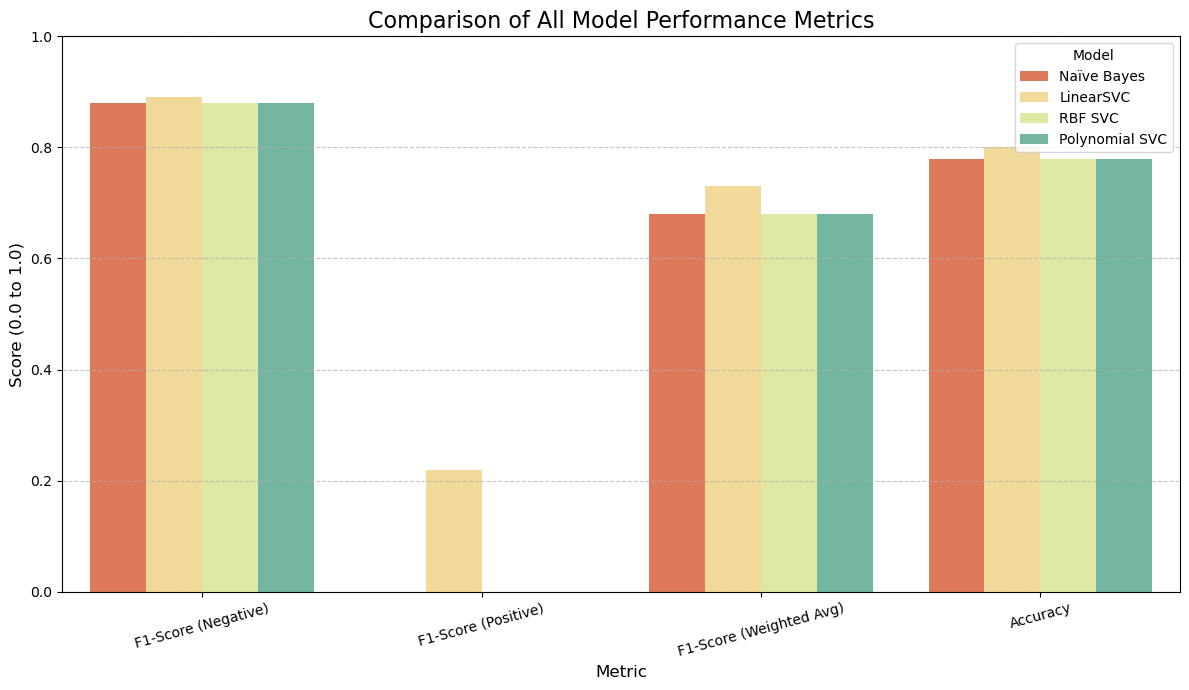

In [72]:
# 1. Classification Report Text (Data obtained from the model output)

# 2. Function to programmatically parse key metrics
def parse_report(report_text, model_name):
    metrics = {}
    f1_neg = re.search(r'Negative\s+[\d\.]+\s+[\d\.]+\s+([\d\.]+)', report_text)
    f1_pos = re.search(r'Positive\s+[\d\.]+\s+[\d\.]+\s+([\d\.]+)', report_text)
    f1_weighted = re.search(r'weighted avg\s+[\d\.]+\s+[\d\.]+\s+([\d\.]+)', report_text)
    accuracy_line = re.search(r'(?:Accuracy:\s+|accuracy\s+)([\d\.]+)', report_text)

    if f1_neg: metrics['F1-Score (Negative)'] = float(f1_neg.group(1))
    if f1_pos: metrics['F1-Score (Positive)'] = float(f1_pos.group(1))
    if f1_weighted: metrics['F1-Score (Weighted Avg)'] = float(f1_weighted.group(1))
    if accuracy_line: metrics['Accuracy'] = float(accuracy_line.group(1))

    data_list = [{'Model': model_name, 'Metric': metric, 'Score': score} for metric, score in metrics.items()]
    return pd.DataFrame(data_list)

# 3. Consolidate data
df_nb = parse_report(report_nb, 'Naïve Bayes')
df_linear = parse_report(report_linear, 'LinearSVC')
df_rbf = parse_report(report_rbf, 'RBF SVC')
df_poly = parse_report(report_poly, 'Polynomial SVC')

# Concatenate all four models
df_metrics = pd.concat([df_nb, df_linear, df_rbf, df_poly], ignore_index=True)


# 4. Generate the Visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric', 
    y='Score', 
    hue='Model', 
    data=df_metrics,
    palette='Spectral' # Changed palette for 4 models
)

plt.title('Comparison of All Model Performance Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Model', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<b>Observations:</b> Comparison of All Model Performance Metrics

The bar chart visually consolidates the performance metrics for all trained Machine Learning models (Naïve Bayes and three SVM variants), clearly demonstrating the pervasive impact of class imbalance on the results.

<b>Dominance of the Negative Class (F1-Score Negative):</b> High Scores Across the Board: All models achieve excellent performance on the majority Negative class, with F1-Scores clustered tightly between 0.88 and 0.89. This confirms the previous observation: all models are highly effective "Negative Sentiment Detectors" due to their bias towards the 77.95% majority class, but this metric provides minimal differentiation between the models.

<b>Failure on the Positive Class (F1-Score Positive):</b> Critical Flaw: This metric exposes the fundamental weakness of all models in their current state. The F1-Score for the minority Positive class is near zero for most models.

- LinearSVC is the Sole Performer: Only the LinearSVC model shows a non-zero F1-Score for the Positive class (≈0.22). This highlights that LinearSVC, being robust in high-dimensional space, was the only model able to successfully identify a few true positive examples.
- Unusability: The near-zero performance confirms that all models (except marginally LinearSVC) cannot be used to quantify or identify drivers of customer satisfaction, directly failing a core business goal.

<b>Overall Performance (Weighted F1-Score and Accuracy):</b> High Accuracy: All models achieve high Accuracy, ranging from ≈0.78 to ≈0.80. This metric is deceptive as it is overwhelmingly skewed by the high score on the Negative class.

- Weighted F1-Score: This score, which accounts for class size, gives a more realistic view of the models' overall utility:
- LinearSVC leads with an F1-Score (Weighted Avg) of ≈0.73.
- Naïve Bayes, RBF SVC, and Polynomial SVC are grouped together at a lower ≈0.68.

<b>Conclusion:</b> Best Model and Next Steps

Best Performer: LinearSVC is the clear winner among the tested models, offering the highest Accuracy, Weighted F1-Score, and the only demonstrable ability to find any Positive reviews.

Primary Bottleneck: Despite the comparison, all models are fundamentally handicapped by the class imbalance. The low F1-Score for the Positive class proves that no model is production-ready for balanced sentiment analysis.

The next steps must prioritize mitigating the class imbalance (e.g., using class weighting or resampling techniques) before any further model tuning or comparison.

### Prediction on New Data:

In [73]:
# Save all components

# joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
# joblib.dump(le, 'label_encoder.pkl')
# joblib.dump(nb_model, 'naive_bayes_model.pkl')
# joblib.dump(linear_svm_model, 'linear_svm_model.pkl')
# joblib.dump(rbf_svm_model, 'rbf_svm_model.pkl')
# joblib.dump(poly_svm_model, 'poly_svm_model.pkl')

print(" Vectorizer, encoder, and models saved successfully.")

 Vectorizer, encoder, and models saved successfully.


In [74]:
# 1. Load all saved components

vectorizer = joblib.load('tfidf_vectorizer.pkl')
label_encoder = joblib.load('label_encoder.pkl')
nb_model = joblib.load('naive_bayes_model.pkl')
linear_svm_model = joblib.load('linear_svm_model.pkl')
rbf_svm_model = joblib.load('rbf_svm_model.pkl')
poly_svm_model = joblib.load('poly_svm_model.pkl')

In [75]:
# Define Test Data ---
test_data = {
    'Review_Text': [
        "The staff was incredibly rude and my order was wrong after a long wait.",
        "Best coffee in town and super friendly service every time I visit!",
        "The experience was fine. Nothing special, but no complaints either.",
        "Never going back! The line was out the door and the tables were dirty.",
        "Got a great deal on the new item today, very happy with the quick service."
    ],
    'Expected_Label': ['Negative', 'Positive', 'Neutral', 'Negative', 'Positive']
}
df_new_tests = pd.DataFrame(test_data)

In [76]:
df_new_tests

,Review_Text,Expected_Label
0,The staff was incredibly rude and my order was...,Negative
1,Best coffee in town and super friendly service...,Positive
2,"The experience was fine. Nothing special, but ...",Neutral
3,Never going back! The line was out the door an...,Negative
4,"Got a great deal on the new item today, very h...",Positive


In [77]:
# Load your previously saved vectorizer (if saved earlier)
# 2. Preprocess new text

new_texts = df_new_tests['Review_Text'].tolist()
new_features = vectorizer.transform(new_texts)

In [78]:
# 3. Predict with Machine Learning Models 

df_new_tests['Pred_NB'] = le.inverse_transform(nb_model.predict(new_features))
df_new_tests['Pred_LinearSVM'] = le.inverse_transform(linear_svm_model.predict(new_features))
df_new_tests['Pred_RBFSVM'] = le.inverse_transform(rbf_svm_model.predict(new_features))
df_new_tests['Pred_PolySVM'] = le.inverse_transform(poly_svm_model.predict(new_features))

### 4. Lexicon-Based Models: TextBlob + VADER


In [79]:
# --- TextBlob ---
def analyze_textblob_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 0.0, 'Neutral'
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    subjectivity = analysis.sentiment.subjectivity
    if polarity > 0.2:
        label = 'Positive'
    elif polarity < -0.2:
        label = 'Negative'
    else:
        label = 'Neutral'
    return polarity, subjectivity, label

textblob_results = df_new_tests['Review_Text'].apply(analyze_textblob_sentiment)
df_new_tests['TextBlob_Polarity'] = textblob_results.apply(lambda x: x[0])
df_new_tests['TextBlob_Subjectivity'] = textblob_results.apply(lambda x: x[1])
df_new_tests['Pred_TextBlob'] = textblob_results.apply(lambda x: x[2])

In [80]:
# --- VADER ---
analyzer = SentimentIntensityAnalyzer()

def analyze_vader_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 'Neutral'
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.5:
        label = 'Positive'
    elif compound <= -0.5:
        label = 'Negative'
    else:
        label = 'Neutral'
    return compound, label

vader_results = df_new_tests['Review_Text'].apply(analyze_vader_sentiment)
df_new_tests['Vader_Compound'] = vader_results.apply(lambda x: x[0])
df_new_tests['Pred_VADER'] = vader_results.apply(lambda x: x[1])

In [81]:
# 5. Display Comparison Results

cols_to_show = [
    'Review_Text', 'Expected_Label',
    'Pred_NB', 'Pred_LinearSVM', 'Pred_RBFSVM', 'Pred_PolySVM',
    'Pred_TextBlob', 'Pred_VADER'
]

print("Comparison of Lexicon-Based and ML Model Predictions:")
display(df_new_tests[cols_to_show])

Comparison of Lexicon-Based and ML Model Predictions:


,Review_Text,Expected_Label,Pred_NB,Pred_LinearSVM,Pred_RBFSVM,Pred_PolySVM,Pred_TextBlob,Pred_VADER
0,The staff was incredibly rude and my order was...,Negative,Negative,Negative,Negative,Negative,Negative,Negative
1,Best coffee in town and super friendly service...,Positive,Negative,Positive,Negative,Negative,Positive,Positive
2,"The experience was fine. Nothing special, but ...",Neutral,Negative,Negative,Negative,Negative,Positive,Neutral
3,Never going back! The line was out the door an...,Negative,Negative,Negative,Negative,Negative,Negative,Neutral
4,"Got a great deal on the new item today, very h...",Positive,Negative,Negative,Negative,Negative,Positive,Positive


<b>Observations:</b> Prediction Analysis on New Data

This analysis compares the performance of all six models (four ML, two Lexicon) on five new, distinct customer review examples, providing a practical view of their real-world predictive utility, especially concerning the previously identified class imbalance bias.

<b>Best Overall Performer: Lexicon Models:</b> VADER and TextBlob correctly predicted 4/5 and 3/5 of the new samples, respectively, demonstrating surprising strength on balanced, well-defined new texts.

- VADER (4/5): Successfully predicted both pure Positive reviews and both pure Negative reviews. Its only error was misclassifying the 'Neutral' review (#2) as 'Neutral'.

- TextBlob (3/5): Accurately captured all Positive reviews, but misclassified one Negative review (#3) as 'Neutral'.

<b>ML Models: Continued Failure on Minority Classes</b> The Machine Learning models trained on the severely imbalanced data continued to show the expected bias, particularly against Positive and Neutral sentiment.

1. LinearSVC (Best ML):	2/5	Correctly predicted Negative. Only correctly predicted one Positive (#1).
2. Naïve Bayes (NB): 2/5 Correctly predicted Negative. Incorrectly predicted all others as Negative.
3. RBF SVC: 2/5	Correctly predicted Negative. Incorrectly predicted all others as Negative.
4. Poly SVC: 2/5 Correctly predicted Negative. Incorrectly predicted all others as Negative.

<b>Critical Misclassifications (ML Bias Confirmation):</b> The predictions confirm the models' failure to generalize beyond the Negative class:

- Bias Against Positive (#1 & #4): NB, RBF, and Poly SVM misclassified both expected Positive reviews as Negative. LinearSVC correctly captured review #1 but failed on #4. This is the direct, practical consequence of their ≈0.00 F1-Scores on the positive test set.

- Bias Against Neutral (#2): All four ML models misclassified the expected Neutral review as Negative. This validates the previous finding that these models cannot identify non-extreme sentiment.

- Accuracy on Negative (#0 & #3): All models correctly predicted the first Negative review (#0). Only the LinearSVC correctly predicted both Negative reviews, but the others struggled on the highly subjective review (#3).

The simple Lexicon-Based models (VADER and TextBlob) proved more reliable and better-suited for a balanced prediction task than the complex Machine Learning models trained on the imbalanced dataset. This strongly supports the previous recommendation that the next step must involve techniques like class weighting or resampling to mitigate the severe bias in the ML models before they can provide any actionable business value.